# Mean Reversion Trading Strategy — Per-Stock Analysis
Strategy applied **independently** on each NIFTY 50 stock using its own close price.

## 1. Load & Clean Data

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

df  = pd.read_csv('data/nifty50_close.csv', parse_dates=['Date'], index_col='Date')
idx = pd.read_csv('data/nifty50_index.csv', parse_dates=['Date'], index_col='Date')

df  = df.ffill().dropna()
idx = idx.ffill().dropna()
common = df.index.intersection(idx.index)
df, idx = df.loc[common], idx.loc[common]

STOCKS = df.columns.tolist()
print(f"Stocks: {len(STOCKS)} | Days: {len(df)} | {df.index[0].date()} → {df.index[-1].date()}")
print(STOCKS)

Stocks: 49 | Days: 1235 | 2021-06-01 → 2026-06-01
['KOTAKBANK', 'M&M', 'ADANIENT', 'APOLLOHOSP', 'VEDL', 'HCLTECH', 'RELIANCE', 'SHREECEM', 'UPL', 'HEROMOTOCO', 'BPCL', 'TITAN', 'SUNPHARMA', 'INDUSINDBK', 'MARUTI', 'HINDUNILVR', 'NESTLEIND', 'HDFCBANK', 'DIVISLAB', 'DRREDDY', 'ITC', 'ADANIPORTS', 'INFY', 'AXISBANK', 'BRITANNIA', 'HINDALCO', 'BHARTIARTL', 'BAJFINANCE', 'NTPC', 'ICICIBANK', 'COALINDIA', 'WIPRO', 'TATACONSUM', 'CIPLA', 'SBIN', 'LT', 'JSWSTEEL', 'ULTRACEMCO', 'POWERGRID', 'ONGC', 'IOC', 'TATASTEEL', 'EICHERMOT', 'BAJAJFINSV', 'GRASIM', 'ASIANPAINT', 'TECHM', 'BAJAJ-AUTO', 'TCS']


## 2. Strategy Parameters

In [45]:
WINDOW      = 20      # rolling z-score window
BUY_Z       = -2.0    # enter long when z < BUY_Z
SELL_Z      =  2.0    # enter short when z > SELL_Z
HOLD_DAYS   =  5      # hold each position for 5 days
COST        =  0.000  # one-way transaction cost (0.1%)

## 3. Per-Stock Backtest
For each stock independently:
1. Compute daily returns from close price
2. Compute rolling 20-day z-score
3. Generate buy/sell signals and simulate 5-day holding period
4. Deduct transaction costs

In [46]:
def backtest_single(prices, window=WINDOW, buy_z=BUY_Z, sell_z=SELL_Z,
                    hold=HOLD_DAYS, cost=COST):
    """Run mean reversion strategy on a single stock's close price series."""
    ret   = prices.pct_change().dropna()
    mu    = ret.rolling(window).mean()
    sigma = ret.rolling(window).std()
    z     = (ret - mu) / sigma

    n = len(ret)
    pos     = np.zeros(n)
    counter = 0
    z_arr   = z.values

    for t in range(1, n):
        if counter > 0:
            pos[t] = pos[t-1]
            counter -= 1
        else:
            pos[t] = 0
            if not np.isnan(z_arr[t-1]):
                if z_arr[t-1] < buy_z:
                    pos[t] = 1
                    counter = hold
                elif z_arr[t-1] > sell_z:
                    pos[t] = -1
                    counter = hold

    gross      = pos * ret.values
    trade_cost = np.abs(np.diff(pos, prepend=0)) * cost
    net        = gross - trade_cost

    return pd.Series(net, index=ret.index), pd.Series(pos, index=ret.index), z


def compute_metrics(daily_ret):
    equity   = (1 + daily_ret).cumprod()
    total    = equity.iloc[-1] - 1
    n_years  = len(daily_ret) / 252
    cagr     = (1 + total) ** (1 / n_years) - 1
    sharpe   = daily_ret.mean() / daily_ret.std() * np.sqrt(252) if daily_ret.std() > 0 else 0
    roll_max = equity.cummax()
    max_dd   = ((equity - roll_max) / roll_max).min()
    active   = daily_ret[daily_ret != 0]
    win_rate = (active > 0).mean() if len(active) > 0 else 0
    n_trades = int((np.diff((daily_ret.values != 0).astype(int)) != 0).sum() / 2)
    return dict(total_ret=total, cagr=cagr, sharpe=sharpe,
                max_dd=max_dd, win_rate=win_rate, n_trades=n_trades, equity=equity)


# Run on every stock
results = {}
for stock in STOCKS:
    net_ret, pos, z = backtest_single(df[stock])
    results[stock] = compute_metrics(net_ret)
    results[stock]['net_ret'] = net_ret

print(f"Backtested {len(results)} stocks.")

Backtested 49 stocks.


## 4. Per-Stock Performance Table

In [47]:
summary = pd.DataFrame({
    s: {
        'Total Return (%)' : round(results[s]['total_ret'] * 100, 2),
        'CAGR (%)'         : round(results[s]['cagr']      * 100, 2),
        'Sharpe Ratio'     : round(results[s]['sharpe'],           3),
        'Max Drawdown (%)'  : round(results[s]['max_dd']    * 100, 2),
        'Win Rate (%)'     : round(results[s]['win_rate']   * 100, 2),
        'Trades'           : results[s]['n_trades'],
    }
    for s in STOCKS
}).T

summary = summary.sort_values('Sharpe Ratio', ascending=False)
summary.index.name = 'Stock'

# Colour-code: green = positive CAGR, red = negative
def colour(val):
    color = 'green' if val > 0 else 'red'
    return f'color: {color}'

display(summary.style
        .applymap(colour, subset=['CAGR (%)', 'Total Return (%)'])
        .format(precision=2)
        .set_caption('Mean Reversion Strategy — Per-Stock Results (sorted by Sharpe)'))

,Total Return (%),CAGR (%),Sharpe Ratio,Max Drawdown (%),Win Rate (%),Trades
Stock,,,,,,
TATASTEEL,134.24,18.98,1.11,-15.25,54.11,49.00
BHARTIARTL,57.03,9.65,0.84,-14.00,53.50,50.00
VEDL,100.48,15.26,0.81,-33.60,57.14,42.00
KOTAKBANK,41.45,7.34,0.70,-15.80,55.00,47.00
GRASIM,32.11,5.85,0.58,-15.02,52.71,42.00
JSWSTEEL,46.11,8.05,0.57,-19.38,54.06,42.00
ITC,29.47,5.42,0.54,-15.32,50.98,49.00
COALINDIA,42.42,7.49,0.54,-35.24,52.22,50.00
ONGC,45.52,7.96,0.52,-16.65,50.57,44.00


## 5. Benchmark Metrics (NIFTY 50 Buy & Hold)

In [48]:
# Compute NIFTY 50 buy-and-hold benchmark metrics
bm_ret    = idx.squeeze().pct_change().dropna()
bm_equity = (1 + bm_ret).cumprod()
bm_total  = bm_equity.iloc[-1] - 1
bm_nyears = len(bm_ret) / 252
bm_cagr   = (1 + bm_total) ** (1 / bm_nyears) - 1
bm_sharpe = bm_ret.mean() / bm_ret.std() * np.sqrt(252)

print(f"Benchmark (NIFTY 50 B&H) CAGR  : {bm_cagr*100:.2f}%")
print(f"Benchmark (NIFTY 50 B&H) Sharpe: {bm_sharpe:.3f}")

Benchmark (NIFTY 50 B&H) CAGR  : 8.65%
Benchmark (NIFTY 50 B&H) Sharpe: 0.672


## 6. Visualizations
### 6a. Equity Curves — Top 10 vs Bottom 10 Stocks

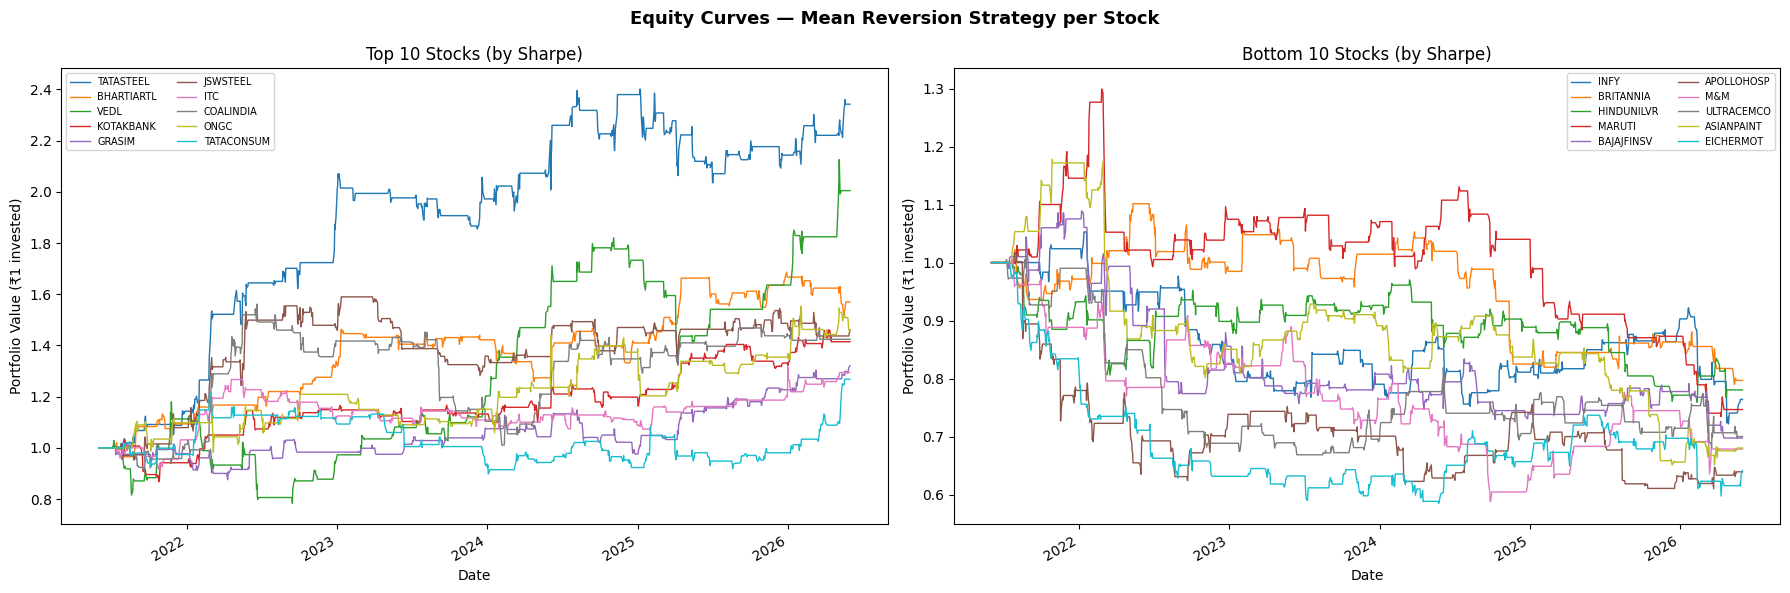

In [49]:
top10    = summary.head(10).index.tolist()
bottom10 = summary.tail(10).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Equity Curves — Mean Reversion Strategy per Stock', fontsize=13, fontweight='bold')

for stock in top10:
    results[stock]['equity'].plot(ax=axes[0], label=stock, linewidth=1)
axes[0].set_title('Top 10 Stocks (by Sharpe)')
axes[0].set_ylabel('Portfolio Value (₹1 invested)')
axes[0].legend(fontsize=7, ncol=2)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for stock in bottom10:
    results[stock]['equity'].plot(ax=axes[1], label=stock, linewidth=1)
axes[1].set_title('Bottom 10 Stocks (by Sharpe)')
axes[1].set_ylabel('Portfolio Value (₹1 invested)')
axes[1].legend(fontsize=7, ncol=2)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('plots/per_stock_equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 6b. CAGR Bar Chart — All Stocks

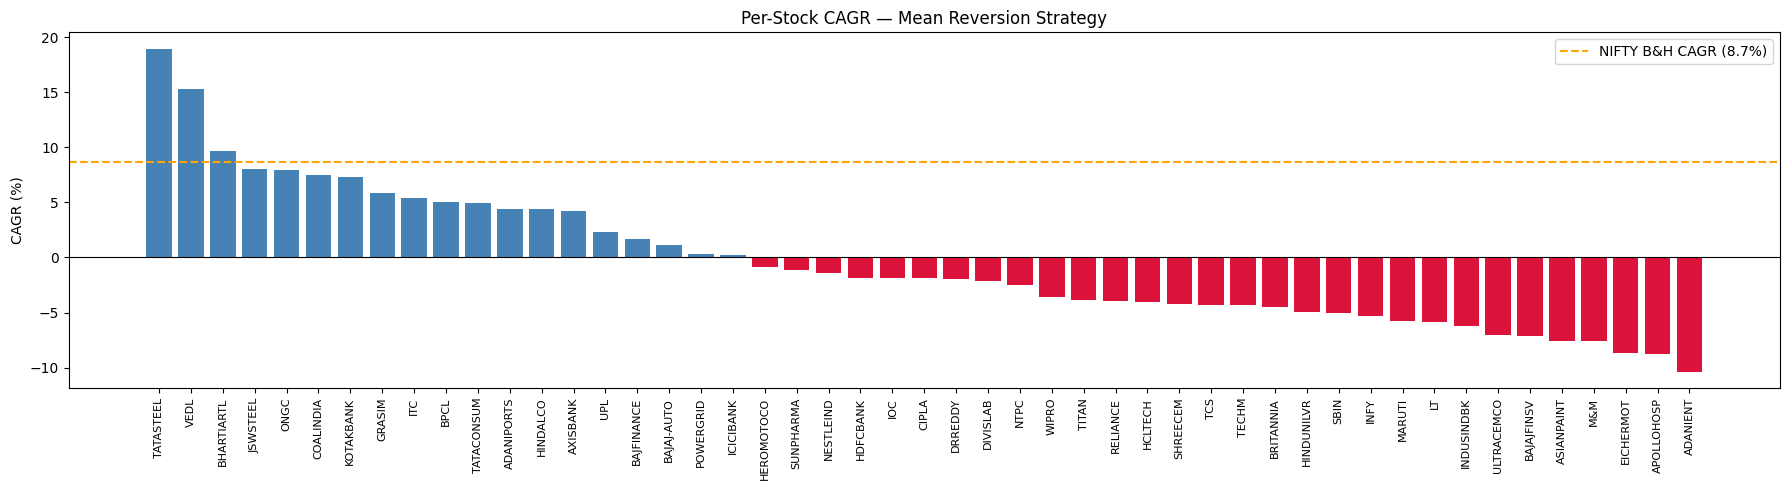

In [50]:
cagr_series = summary['CAGR (%)'].sort_values(ascending=False)
colors = ['steelblue' if v > 0 else 'crimson' for v in cagr_series]

plt.figure(figsize=(18, 5))
plt.bar(cagr_series.index, cagr_series.values, color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.axhline(bm_cagr * 100, color='orange', linewidth=1.5, linestyle='--', label=f'NIFTY B&H CAGR ({bm_cagr*100:.1f}%)')
plt.xticks(rotation=90, fontsize=8)
plt.title('Per-Stock CAGR — Mean Reversion Strategy')
plt.ylabel('CAGR (%)')
plt.legend()
plt.tight_layout()
plt.savefig('plots/per_stock_cagr.png', dpi=150, bbox_inches='tight')
plt.show()

### 6c. Sharpe Ratio Bar Chart — All Stocks

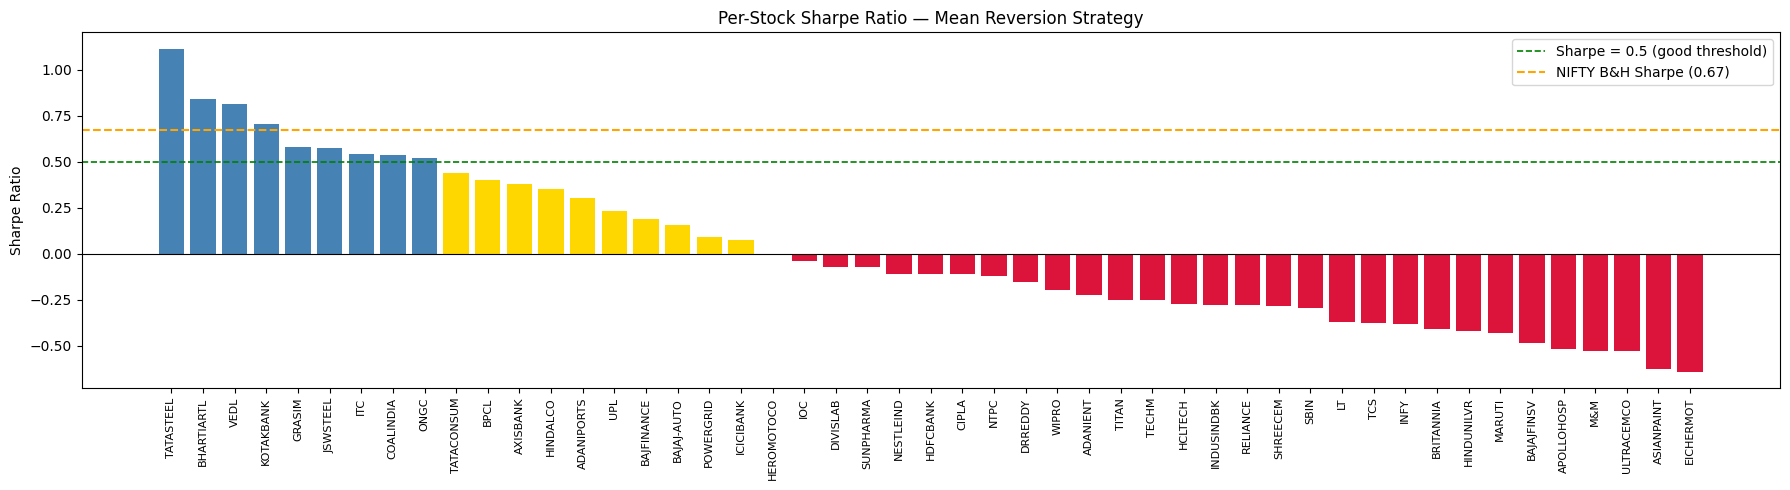

In [51]:
sharpe_series = summary['Sharpe Ratio'].sort_values(ascending=False)
colors = ['steelblue' if v > 0.5 else ('gold' if v > 0 else 'crimson') for v in sharpe_series]

plt.figure(figsize=(18, 5))
plt.bar(sharpe_series.index, sharpe_series.values, color=colors)
plt.axhline(0,   color='black',  linewidth=0.8)
plt.axhline(0.5, color='green',  linewidth=1.2, linestyle='--', label='Sharpe = 0.5 (good threshold)')
plt.axhline(bm_sharpe, color='orange', linewidth=1.5, linestyle='--', label=f'NIFTY B&H Sharpe ({bm_sharpe:.2f})')
plt.xticks(rotation=90, fontsize=8)
plt.title('Per-Stock Sharpe Ratio — Mean Reversion Strategy')
plt.ylabel('Sharpe Ratio')
plt.legend()
plt.tight_layout()
plt.savefig('plots/per_stock_sharpe.png', dpi=150, bbox_inches='tight')
plt.show()

### 6d. Drawdown Chart — Top 5 Stocks

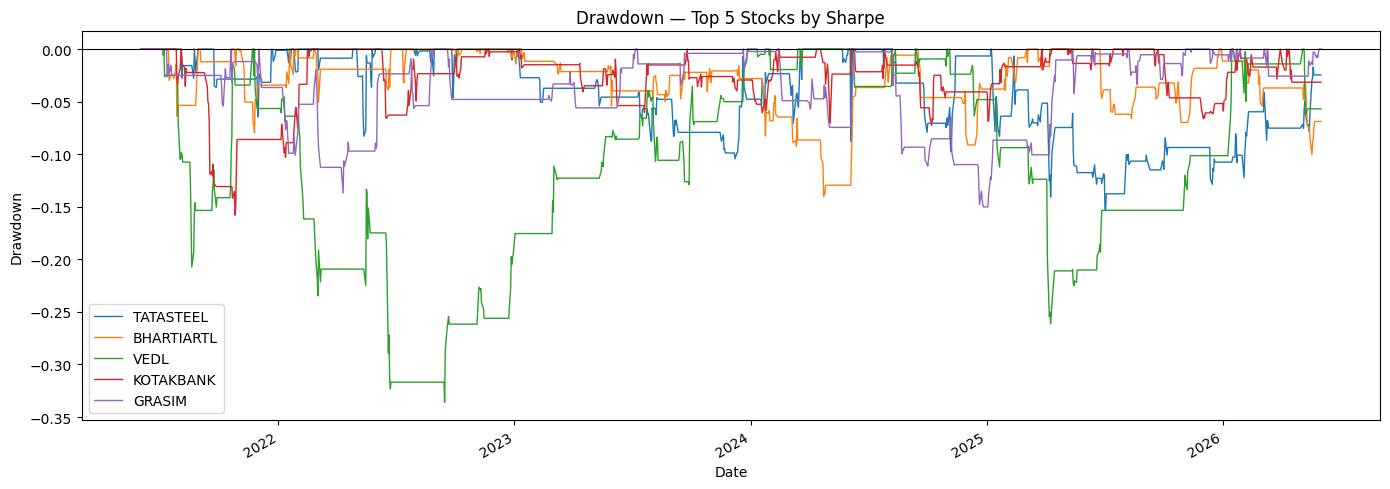

In [52]:
top5 = summary.head(5).index.tolist()

plt.figure(figsize=(14, 5))
for stock in top5:
    eq  = results[stock]['equity']
    dd  = (eq - eq.cummax()) / eq.cummax()
    dd.plot(label=stock, linewidth=1)

plt.axhline(0, color='black', linewidth=0.8)
plt.title('Drawdown — Top 5 Stocks by Sharpe')
plt.ylabel('Drawdown')
plt.legend()
plt.tight_layout()
plt.savefig('plots/per_stock_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Overall Conclusion

In [55]:
avg_cagr   = summary['CAGR (%)'].mean()
avg_sharpe = summary['Sharpe Ratio'].mean()
good       = summary[(summary['Sharpe Ratio'] > 0.5) & (summary['CAGR (%)'] > 0)]
pct_good   = len(good) / len(STOCKS) * 100

print("=" * 60)
print("  OVERALL CONCLUSION")
print("=" * 60)
print(f"  Stocks analysed       : {len(STOCKS)}")
print(f"  Avg CAGR (strategy)   : {avg_cagr:.2f}%")
print(f"  Avg Sharpe (strategy) : {avg_sharpe:.3f}")
print(f"  Benchmark CAGR        : {bm_cagr*100:.2f}%")
print(f"  Benchmark Sharpe      : {bm_sharpe:.3f}")
print(f"  Stocks where strategy works well: {len(good)} ({pct_good:.0f}%)")
print()
if avg_sharpe > bm_sharpe:
    print("On average, mean reversion BEATS the benchmark on a risk-adjusted basis.")
else:
    print("On average, mean reversion TRAILS the benchmark on a risk-adjusted basis.")
print()
print(f"  Best stocks  : {summary.head(10).index.tolist()}")
print(f"  Worst stocks : {summary.tail(10).index.tolist()}")
print("=" * 60)

# Save summary table
summary.drop(columns='equity' if 'equity' in summary.columns else []).to_csv('results/per_stock_metrics.csv')
print("\nSaved to results/per_stock_metrics.csv")

  OVERALL CONCLUSION
  Stocks analysed       : 49
  Avg CAGR (strategy)   : -0.49%
  Avg Sharpe (strategy) : 0.000
  Benchmark CAGR        : 8.65%
  Benchmark Sharpe      : 0.672
  Stocks where strategy works well: 9 (18%)

On average, mean reversion TRAILS the benchmark on a risk-adjusted basis.

  Best stocks  : ['TATASTEEL', 'BHARTIARTL', 'VEDL', 'KOTAKBANK', 'GRASIM', 'JSWSTEEL', 'ITC', 'COALINDIA', 'ONGC', 'TATACONSUM']
  Worst stocks : ['INFY', 'BRITANNIA', 'HINDUNILVR', 'MARUTI', 'BAJAJFINSV', 'APOLLOHOSP', 'M&M', 'ULTRACEMCO', 'ASIANPAINT', 'EICHERMOT']

Saved to results/per_stock_metrics.csv
